In [3]:
import math
import random
import numpy as np
import mesa
from mesa.space import SingleGrid
import matplotlib.pyplot as plt


In [4]:
class Klausimier_Model(mesa.Model):
    def __init__(self, n=50, rng=None):
        super().__init__(rng=rng)
        self.grid = SingleGrid(n,n, torus=True)
        self.n = n

        agent_id = 0
        cx, cy = n // 2, n // 2
        for x in range(n):
            for y in range(n):
                plant = 0.5 + random.uniform(0.0, 0.05)
                water = 10. + random.uniform(-0.1, 0.1)

                agente = AgenteSavana(model=self, plant = plant, water = water)
                self.grid.place_agent(agente, (x, y))
    def step(self):
        for agent in self.agents:
            agent.prepare_update()

        for agent in self.agents:
            agent.apply_update()

    def export(self):
        matrix_act = np.zeros((self.n, self.n))
        matrix_ini = np.zeros((self.n, self.n))
        for agent, (x, y) in self.grid.coord_iter():
            if agent:
                matrix_act[x, y] = agent.plant
                matrix_ini[x, y] = agent.water
        return matrix_act

6


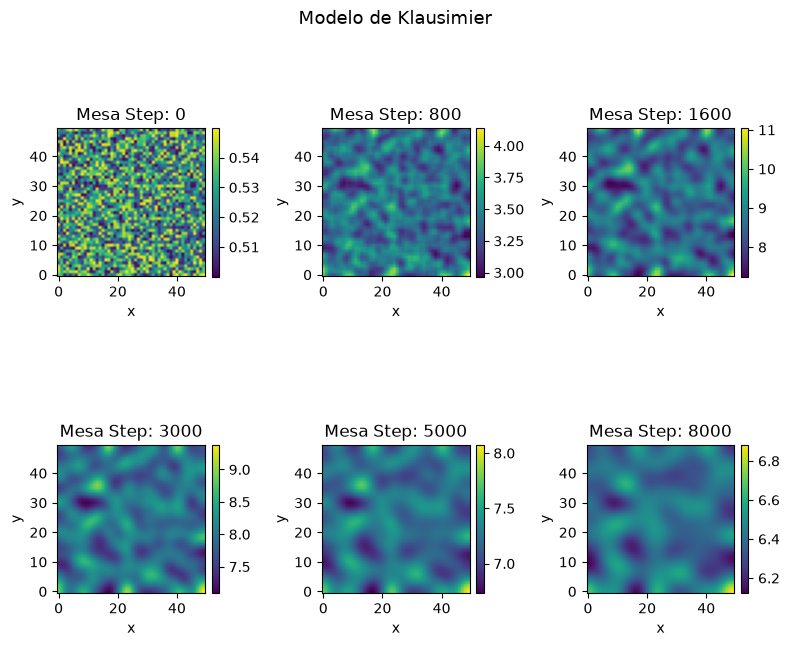

In [5]:
class AgenteSavana(mesa.Agent):
    def __init__(self, model, plant, water):
        taxa_diff_plant = 1
        taxa_diff_water = 185.5
        plant_loss_rate = 0.45
        rainfall = 2.0
        dX = 0.5
        dY = 0.5

        super().__init__(model)
        self.rainfall = rainfall
        self.taxa_diff_plant = taxa_diff_plant
        self.plant_loss_rate = plant_loss_rate
        self.plant = plant
        self.proximo_plant = plant
        self.passo_tempo = 0.00025
        self.taxa_diff_water = taxa_diff_water
        self.water = water
        self.proximo_qtd_water = water
        self.dX = dX
        self.dY = dY


    def prepare_update(self):
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=False, include_center=False
        )

        Left_Act, Right_Act, Up_Act, Down_Act = self.plant, self.plant, self.plant, self.plant
        Left_Ini, Right_Ini, Up_Ini, Down_Ini = self.water, self.water, self.water, self.water

        x, y = self.pos
        for v in neighbors:
            vx, vy = v.pos
            if vx == x - 1 and vy == y:
                Left_Act = v.plant
                Left_Ini = v.water
            elif vx == x + 1 and vy == y:
                Right_Act = v.plant
                Right_Ini = v.water
            elif vx == x and vy == y + 1:
                Up_Act = v.plant
                Up_Ini = v.water
            elif vx == x and vy == y - 1:
                Down_Act = v.plant
                Down_Ini = v.water

        act_laplacian = ((Left_Act + Right_Act - 2 * self.plant) / self.dX / self.dX + (
                    Up_Act + Down_Act - 2 * self.plant) / self.dX / self.dX)

        ini_laplacian = ((Left_Ini + Right_Ini - 2 * self.water) / self.dY / self.dY + (
            Up_Ini + Down_Ini - 2 * self.water) / self.dY / self.dY)

        plantUpTake = self.water * (self.plant ** 2)
        plantLoss = self.plant_loss_rate * self.plant

        self.proximo_qtd_plant = self.plant + (plantUpTake - plantLoss + self.taxa_diff_plant * act_laplacian) * self.passo_tempo
        self.proximo_qtd_water = self.water + (self.rainfall - self.water - plantUpTake + self.taxa_diff_water * ini_laplacian) * self.passo_tempo


    def apply_update(self):
        self.plant = self.proximo_qtd_plant
        self.water = self.proximo_qtd_water


model = Klausimier_Model(n=50)

steps_to_capture = [0, 800, 1600, 3000, 5000, 8000]
snapshots = []

for ste in range(8001):
    if ste in steps_to_capture:
        snapshots.append((ste, model.export()))
    model.step()

numShapes = len(snapshots)
cols = 3
rows = math.ceil(numShapes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(8, 7))
axes = axes.flatten()
print(len(snapshots))
for idx, (s, data) in enumerate(snapshots):
    im = axes[idx].imshow(data, cmap='viridis', origin='lower')
    axes[idx].set_title(f'Mesa Step: {s}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Modelo de Klausimier', fontsize=13)
plt.tight_layout()
plt.show()

np.set_printoptions(precision=1, suppress=True, linewidth=150)